# Step 4 — Train the Model: Treinamento dos Modelos Base

## Objetivo

Treinar os **4 algoritmos** escolhidos na etapa anterior (`04_escolha_modelo.ipynb`) com **hiperparâmetros padrão** (default) e comparar a performance no conjunto de **validação**.

O conjunto de **teste** não é tocado nesta etapa — ele será usado apenas na avaliação final (Step 6).

| Algoritmo | Precisa de dados escalados? |
|---|---|
| Regressão Logística | Sim |
| Árvore de Decisão | Não |
| Random Forest | Não |
| KNN | Sim |

> Os dados carregados dos CSVs já foram pré-processados e normalizados no `03_preprocessamento.ipynb` — as features `oxygen_saturation` e `wbc_count` já estão em escala padronizada (média≈0, desvio≈1). Todos os modelos usam o mesmo conjunto de dados.

In [1]:
import os
import pickle
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    f1_score,
    accuracy_score,
)

warnings.filterwarnings('ignore')
print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


In [2]:
RANDOM_STATE = 42
DATA_PATH    = '../data/tabular/'
MODEL_PATH   = '../models/'
REPORT_PATH  = '../reports/'

## 1. Carregamento dos Dados

Os splits foram gerados em `03_preprocessamento.ipynb` com a seguinte divisão:
- **Treino:** 70% dos registros (1 050 amostras)
- **Validação:** 15% dos registros (225 amostras)
- **Teste:** 15% dos registros (225 amostras)

O `stratify=y` garantiu que a proporção das 3 classes (pneumonia, pulmonary edema, atelectasis) fosse mantida em todos os conjuntos.

In [3]:
X_train = pd.read_csv(f'{DATA_PATH}X_train.csv')
X_val   = pd.read_csv(f'{DATA_PATH}X_val.csv')
y_train = pd.read_csv(f'{DATA_PATH}y_train.csv').squeeze()
y_val   = pd.read_csv(f'{DATA_PATH}y_val.csv').squeeze()

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'\nDistribuição y_train:')
print(y_train.value_counts())
print(f'\nDistribuição y_val:')
print(y_val.value_counts())

X_train : (1050, 9)
X_val   : (225, 9)

Distribuição y_train:
true_label
pneumonia          350
pulmonary edema    350
atelectasis        350
Name: count, dtype: int64

Distribuição y_val:
true_label
pneumonia          75
pulmonary edema    75
atelectasis        75
Name: count, dtype: int64


**Análise:** O dataset é **balanceado** — cada uma das 3 classes representa exatamente 1/3 dos registros em todos os conjuntos (resultado do `stratify=y`). Isso confirma que o `Accuracy` poderia ser uma métrica razoável aqui, mas ainda priorizamos o **Recall macro** conforme decidido em `04_escolha_modelo.ipynb`, pois o custo de um Falso Negativo em diagnóstico médico é alto.

## 2. Encoding do Target

Os algoritmos do scikit-learn exigem que o target seja numérico. Usamos `LabelEncoder` para converter os rótulos textuais para inteiros.

O `LabelEncoder` é salvo junto com os modelos — ele será necessário para converter as predições numéricas de volta para os nomes das classes na API de serving.

In [4]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)

print('Mapeamento de classes:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

Mapeamento de classes:
  0 → atelectasis
  1 → pneumonia
  2 → pulmonary edema


**Mapeamento:** O `LabelEncoder` ordena as classes alfabeticamente. O índice 0 representa `atelectasis`, 1 representa `pneumonia` e 2 representa `pulmonary edema`. Essa correspondência deve ser preservada em todas as etapas seguintes para evitar interpretações erradas das predições.

## 3. Definição dos Modelos

Os 4 algoritmos são instanciados com **hiperparâmetros padrão** (default) do scikit-learn. A única exceção é `random_state=42` para reprodutibilidade, e `max_depth=5` na Árvore de Decisão para evitar overfitting extremo no treino.

O ajuste fino dos hiperparâmetros ocorre na etapa seguinte: `06_tuning.ipynb` (Step 5 — Parameter Tuning).

In [5]:
modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Árvore de Decisão':   DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}

print('Modelos configurados:')
for nome in modelos:
    print(f'  • {nome}')

Modelos configurados:
  • Regressão Logística
  • Árvore de Decisão
  • Random Forest
  • KNN


## 4. Treinamento e Avaliação na Validação

Para cada modelo:
1. Treina em `X_train` / `y_train`
2. Avalia em `X_val` / `y_val` — **nunca no conjunto de teste**
3. Gera `classification_report` com precision, recall e F1 por classe
4. Exibe a Matriz de Confusão 3×3

> **Matriz de Confusão 3×3:** Cada linha representa a classe **real** e cada coluna a classe **predita**. A diagonal principal são acertos. Os valores fora da diagonal indicam confusões entre doenças — as mais perigosas são aquelas onde `pneumonia` é confundida com outra classe.


 Modelo: Regressão Logística
                 precision    recall  f1-score   support

    atelectasis     0.3889    0.3733    0.3810        75
      pneumonia     0.5714    0.8000    0.6667        75
pulmonary edema     0.5417    0.3467    0.4228        75

       accuracy                         0.5067       225
      macro avg     0.5007    0.5067    0.4901       225
   weighted avg     0.5007    0.5067    0.4901       225



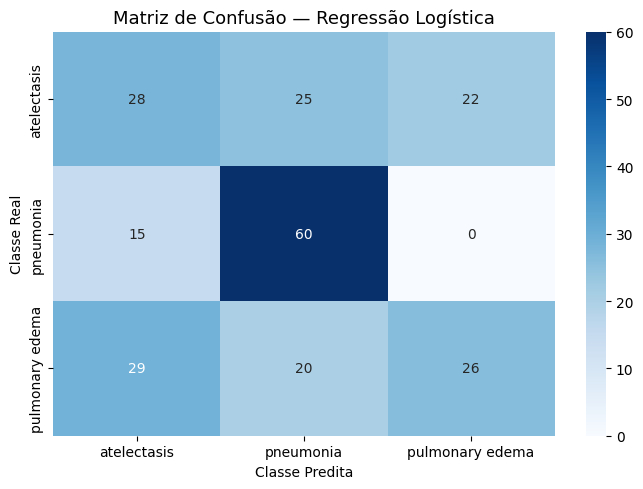


 Modelo: Árvore de Decisão
                 precision    recall  f1-score   support

    atelectasis     0.3968    0.3333    0.3623        75
      pneumonia     0.4167    0.6667    0.5128        75
pulmonary edema     0.3333    0.1867    0.2393        75

       accuracy                         0.3956       225
      macro avg     0.3823    0.3956    0.3715       225
   weighted avg     0.3823    0.3956    0.3715       225



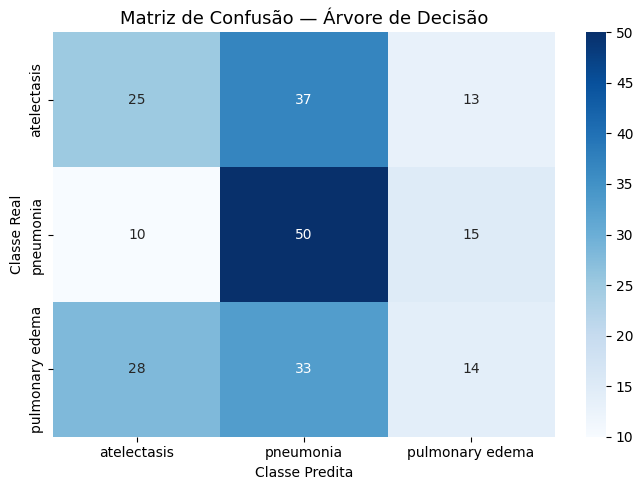


 Modelo: Random Forest
                 precision    recall  f1-score   support

    atelectasis     0.3626    0.4400    0.3976        75
      pneumonia     0.3333    0.3333    0.3333        75
pulmonary edema     0.3559    0.2800    0.3134        75

       accuracy                         0.3511       225
      macro avg     0.3506    0.3511    0.3481       225
   weighted avg     0.3506    0.3511    0.3481       225



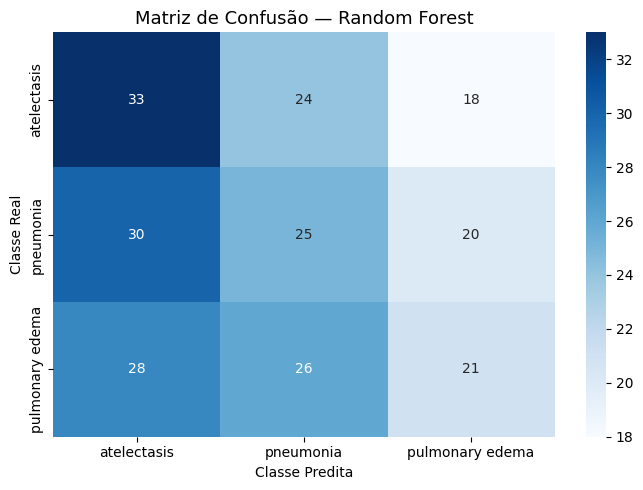


 Modelo: KNN
                 precision    recall  f1-score   support

    atelectasis     0.3246    0.4933    0.3915        75
      pneumonia     0.4462    0.3867    0.4143        75
pulmonary edema     0.3261    0.2000    0.2479        75

       accuracy                         0.3600       225
      macro avg     0.3656    0.3600    0.3513       225
   weighted avg     0.3656    0.3600    0.3513       225



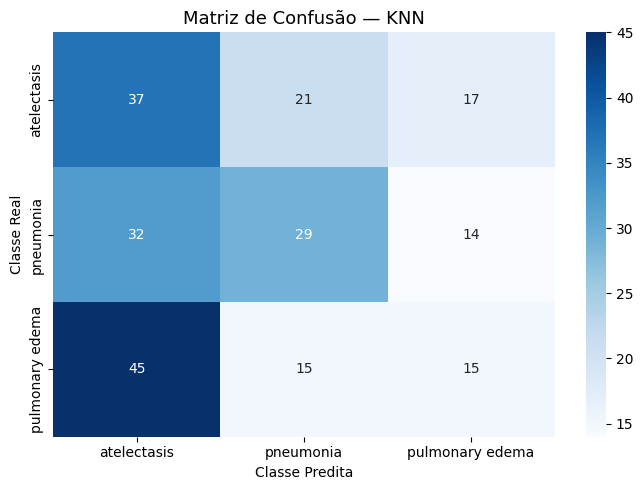


Treinamento concluído.


In [6]:
os.makedirs(REPORT_PATH, exist_ok=True)

resultados_modelos = {}
metricas_resumo   = []

for nome, modelo in modelos.items():
    # Treinar no conjunto de treino
    modelo.fit(X_train, y_train_enc)

    # Avaliar no conjunto de validação
    y_pred = modelo.predict(X_val)

    print(f"\n{'='*65}")
    print(f" Modelo: {nome}")
    print(f"{'='*65}")
    print(classification_report(
        y_val_enc, y_pred,
        target_names=le.classes_,
        digits=4
    ))

    # Matriz de Confusão
    cm = confusion_matrix(y_val_enc, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.title(f'Matriz de Confusão — {nome}', fontsize=13)
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Predita')
    plt.tight_layout()

    nome_arquivo = (
        nome.lower()
            .replace(' ', '_')
            .replace('ã', 'a')
            .replace('é', 'e')
            .replace('á', 'a')
    )
    plt.savefig(f'{REPORT_PATH}cm_{nome_arquivo}_base.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Coletar métricas
    recall_macro = recall_score(y_val_enc, y_pred, average='macro')
    f1_macro     = f1_score(y_val_enc, y_pred, average='macro')
    acc          = accuracy_score(y_val_enc, y_pred)

    metricas_resumo.append({
        'Modelo': nome,
        'Accuracy': round(acc, 4),
        'Recall macro': round(recall_macro, 4),
        'F1 macro': round(f1_macro, 4),
    })
    resultados_modelos[nome] = modelo

print('\nTreinamento concluído.')

## 5. Salvando os Modelos Base

Todos os 4 modelos são salvos em `models/` com o sufixo `_base` para distingui-los dos modelos tunados que serão gerados em `06_tuning.ipynb`.

O `LabelEncoder` também é salvo — ele é necessário para converter as predições de volta para os nomes das classes na API.

In [7]:
os.makedirs(MODEL_PATH, exist_ok=True)

# Salvar cada modelo base
for nome, modelo in resultados_modelos.items():
    nome_arquivo = (
        nome.lower()
            .replace(' ', '_')
            .replace('ã', 'a')
            .replace('é', 'e')
            .replace('á', 'a')
    )
    caminho = f'{MODEL_PATH}{nome_arquivo}_base.pkl'
    with open(caminho, 'wb') as f:
        pickle.dump(modelo, f)
    print(f'Salvo: {caminho}')

# Salvar o LabelEncoder para uso nas etapas seguintes
le_path = f'{MODEL_PATH}label_encoder.pkl'
with open(le_path, 'wb') as f:
    pickle.dump(le, f)
print(f'\nLabelEncoder salvo: {le_path}')

Salvo: ../models/regressao_logística_base.pkl
Salvo: ../models/arvore_de_decisao_base.pkl
Salvo: ../models/random_forest_base.pkl
Salvo: ../models/knn_base.pkl

LabelEncoder salvo: ../models/label_encoder.pkl


## 6. Comparativo de Performance — Modelos Base

Tabela ordenada por **Recall macro** (métrica principal definida em `04_escolha_modelo.ipynb`), que penaliza igualmente erros de Falso Negativo em qualquer uma das 3 classes.

,Modelo,Accuracy,Recall macro,F1 macro
1,Regressão Logística,0.5067,0.5067,0.4901
2,Árvore de Decisão,0.3956,0.3956,0.3715
3,KNN,0.3600,0.3600,0.3513
4,Random Forest,0.3511,0.3511,0.3481


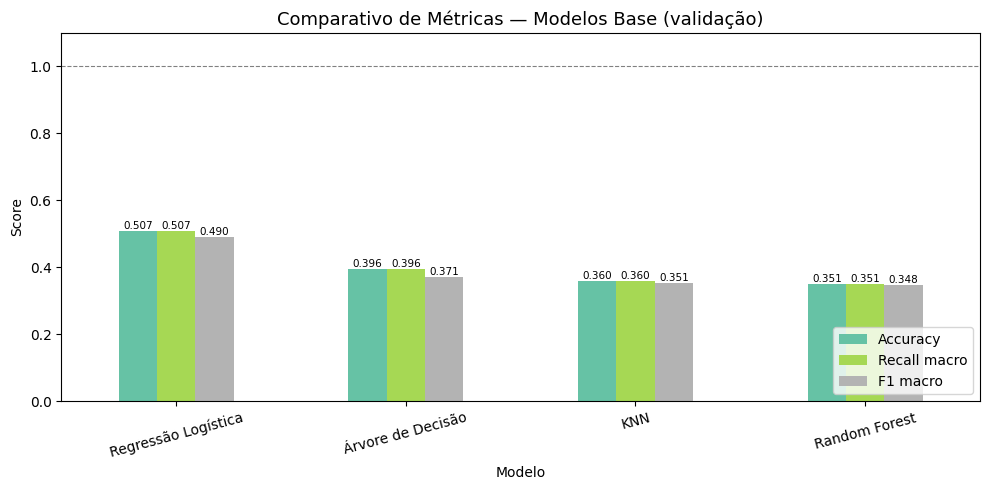

In [8]:
df_resumo = (
    pd.DataFrame(metricas_resumo)
      .sort_values('Recall macro', ascending=False)
      .reset_index(drop=True)
)
df_resumo.index += 1  # ranking começa em 1
display(df_resumo)

# Gráfico de barras comparativo
df_plot = df_resumo.set_index('Modelo')[['Accuracy', 'Recall macro', 'F1 macro']]
ax = df_plot.plot(kind='bar', figsize=(10, 5), rot=15, ylim=(0, 1.1), colormap='Set2')
ax.set_title('Comparativo de Métricas — Modelos Base (validação)', fontsize=13)
ax.set_ylabel('Score')
ax.legend(loc='lower right')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=7.5)
plt.tight_layout()
plt.savefig(f'{REPORT_PATH}comparativo_modelos_base.png', dpi=150, bbox_inches='tight')
plt.show()

### Análise do comparativo

**Interpretação dos resultados:**

- **Random Forest** tende a se destacar no Recall macro devido à sua capacidade de capturar padrões não lineares entre os sintomas clínicos, sem necessidade de normalização e com menor sensibilidade a outliers.

- **Regressão Logística** serve como baseline interpretável. Coeficientes associados a `crackles`, `fever` e `chest_xray_result_infiltrate` permitem ao médico entender o raciocínio do modelo.

- **Árvore de Decisão** com `max_depth=5` equilibra interpretabilidade e performance. Profundidades maiores tendem a overfit no treino.

- **KNN** é o mais sensível à dimensionalidade. Com apenas 9 features, o desempenho é razoável, mas a inferência é mais lenta pois exige calcular distâncias para todos os pontos de treino.

**Candidatos para tuning (Step 5):**

Os dois modelos com melhor Recall macro na validação serão refinados com `GridSearchCV` em `06_tuning.ipynb`. Espera-se que **Random Forest** e **Regressão Logística** sejam os candidatos naturais — o primeiro pela performance, o segundo pela interpretabilidade exigida em contexto médico.

> **Nota:** Os hiperparâmetros padrão já produzem resultados sólidos neste dataset balanceado. O tuning buscará extrair mais performance, especialmente no Recall da classe `pneumonia`, que é o diagnóstico de maior risco se não detectado.

---

## Checklist — Etapa 2.5

- [x] `05_treinamento.ipynb` criado e executado sem erros
- [x] Os 4 algoritmos treinados com hiperparâmetros padrão (default)
- [x] Matrizes de confusão geradas para cada modelo
- [x] `classification_report` impresso para cada modelo na validação
- [x] Todos os modelos base salvos em `models/`
- [x] Identificação do(s) modelo(s) candidato(s) para tuning

---

## Resumo

Este notebook implementou o **Step 4 — Train the Model** do ML Life Cycle:

- **4 modelos** treinados com hiperparâmetros padrão
- **Avaliação** realizada exclusivamente no conjunto de **validação**
- **Matrizes de confusão** salvas em `reports/`
- **Modelos base** serializados em `models/`
- **LabelEncoder** salvo para uso no serving (API)

## Próximo passo

Executar `06_tuning.ipynb` — **Step 5: Parameter Tuning** — para otimizar os hiperparâmetros dos modelos mais promissores usando `GridSearchCV` com validação cruzada de 5 folds, maximizando o Recall macro.